                                    电影票房/评分驱动因素分析

维度	                        说明
核心目标	找出影响电影评分/票房的关键因素，并构建可解释的预测模型
分析方法	数据整合、特征工程、相关性分析、线性回归建模、模型解释
数据源   	Kaggle 的 TMDB 5000 Movie Dataset（两个csv：电影信息 + 演职员）
数据量	    约4,800部电影
技术栈   	Python + Pandas + Matplotlib/Seaborn + Scikit-learn + SHAP
产出物	    Jupyter Notebook + 书面报告 + 特征重要性可视化

一、环境准备与数据导入

1.1 Datasets
tmdb_5000_movies.csv — 电影信息（预算、票房、评分、类型等）
tmdb_5000_credits.csv — 演职员信息（导演、演员）

1.2 导入库并读取数据

In [1]:
# ========== 导入所有需要的库 ==========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 建模相关
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 模型解释（需要 pip install shap）完整命令（ %pip install shap）
import shap

# 设置中文和图片清晰度
from matplotlib.font_manager import FontProperties
font = FontProperties(fname="/home/041f5dea-40df-408c-b3a3-c6dae4b19638/fonts/simsun.ttc")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

# ========== 读取数据 ==========
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

print(f"电影数据: {movies.shape}")   # 预期 (4803, 20)
print(f"演职员数据: {credits.shape}")  # 预期 (4803, 4)

电影数据: (4803, 20)
演职员数据: (4803, 4)


1.3 初看数据面貌

In [2]:
movies.head(3)
movies.info()
credits.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


movies表的关键列：
budget — 预算
revenue — 票房收入
vote_average — 评分（0-10）
vote_count — 评分人数
genres — 类型（JSON格式，如 [{"id":28,"name":"Action"}]）
release_date — 上映日期
runtime — 片长（分钟）
popularity — 流行度
original_language — 语言

credits表的关键列：
crew — 剧组成员（JSON，需从中提取导演）
cast — 演员表（JSON，需提取主要演员）

二、数据清洗与特征工程（项目核心难点）

2.1 解析JSON列：从嵌套结构中提取信息

genres、keywords、production_companies、production_countries 都是以JSON字符串存储的列表，格式类似：
[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}]
我们需要把它们转成Python列表，然后提取或拼接。

In [3]:
import ast

def parse_json_column(column):
    """
    将JSON字符串列解析为Python列表，提取其中的'name'字段
    返回逗号分隔的字符串
    """
    def parse_single(x):
        try:
            items = ast.literal_eval(x)  # 安全解析JSON
            return ', '.join([item['name'] for item in items])
        except:
            return np.nan
    return column.apply(parse_single)

def extract_director(crew_str):
    """从crew JSON中提取导演名字"""
    try:
        crew_list = ast.literal_eval(crew_str)
        for person in crew_list:
            if person['job'] == 'Director':
                return person['name']
        return np.nan
    except:
        return np.nan

def extract_top_actors(cast_str, n=3):
    """从cast JSON中提取前n个主要演员"""
    try:
        cast_list = ast.literal_eval(cast_str)
        return ', '.join([actor['name'] for actor in cast_list[:n]])
    except:
        return np.nan

# ===== 对movies表解析JSON列 =====
movies['genres_parsed'] = parse_json_column(movies['genres'])
movies['keywords_parsed'] = parse_json_column(movies['keywords'])
movies['production_companies_parsed'] = parse_json_column(movies['production_companies'])
movies['production_countries_parsed'] = parse_json_column(movies['production_countries'])

# ===== 从credits表提取导演和演员 =====
credits['director'] = credits['crew'].apply(extract_director)
credits['top_actors'] = credits['cast'].apply(lambda x: extract_top_actors(x, n=3))

# 确认解析成功
print(movies[['genres', 'genres_parsed']].head(3))
print(credits[['director', 'top_actors']].head(3))

                                              genres  \
0  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                 genres_parsed  
0  Action, Adventure, Fantasy, Science Fiction  
1                   Adventure, Fantasy, Action  
2                     Action, Adventure, Crime  
         director                                      top_actors
0   James Cameron  Sam Worthington, Zoe Saldana, Sigourney Weaver
1  Gore Verbinski     Johnny Depp, Orlando Bloom, Keira Knightley
2      Sam Mendes      Daniel Craig, Christoph Waltz, Léa Seydoux


结果：
原始列从 [{"id":28, "name":"Action"...] 变成了干净的可读字符串 "Action, Adventure, Fantasy"。

2.2 合并两张表

In [4]:
# 确保两表的movie_id匹配
movies = movies.rename(columns={'id': 'movie_id'})

# 合并
df = movies.merge(credits[['movie_id', 'title', 'director', 'top_actors']], 
                   on=['movie_id', 'title'], how='inner')

print(f"合并后数据: {df.shape}")
df.head(2)

合并后数据: (4803, 26)


,budget,genres,homepage,movie_id,keywords,original_language,original_title,overview,popularity,production_companies,...,tagline,title,vote_average,vote_count,genres_parsed,keywords_parsed,production_companies_parsed,production_countries_parsed,director,top_actors
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,Enter the World of Pandora.,Avatar,7.2,11800,"Action, Adventure, Fantasy, Science Fiction","culture clash, future, space war, space colony...","Ingenious Film Partners, Twentieth Century Fox...","United States of America, United Kingdom",James Cameron,"Sam Worthington, Zoe Saldana, Sigourney Weaver"
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"Adventure, Fantasy, Action","ocean, drug abuse, exotic island, east india t...","Walt Disney Pictures, Jerry Bruckheimer Films,...",United States of America,Gore Verbinski,"Johnny Depp, Orlando Bloom, Keira Knightley"


2.3 处理缺失值与异常值（关键步骤）

In [5]:
# 查看缺失值
print("缺失值统计:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 关键决策：budget和revenue为0的是无效数据，需要过滤
print(f"\n预算为0的电影数: {(df['budget'] == 0).sum()}")
print(f"票房为0的电影数: {(df['revenue'] == 0).sum()}")

# 过滤：保留预算>0且票房>0的电影（这是行业惯例）
df_clean = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()
print(f"过滤后剩余: {df_clean.shape[0]} 部电影")

# 去掉vote_count为0的（没人投票就没有参考意义）
df_clean = df_clean[df_clean['vote_count'] > 0].copy()

# runtime为0的也去掉
df_clean = df_clean[df_clean['runtime'] > 0].copy()

print(f"最终用于分析: {df_clean.shape[0]} 部电影")

# 对少量缺失的类别列填充Unknown
for col in ['genres_parsed', 'keywords_parsed', 'production_companies_parsed', 
            'production_countries_parsed', 'homepage', 'tagline', 'director', 'top_actors']:
    df_clean[col] = df_clean[col].fillna('Unknown')

缺失值统计:
homepage        3091
overview           3
release_date       1
runtime            2
tagline          844
director          30
dtype: int64

预算为0的电影数: 1037
票房为0的电影数: 1427
过滤后剩余: 3229 部电影
最终用于分析: 3227 部电影


2.4 核心特征工程：创造有价值的变量

In [6]:
# ===== 1. 上映月份、季度和年份（从release_date提取） =====
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')
df_clean['release_month'] = df_clean['release_date'].dt.month
df_clean['release_quarter'] = df_clean['release_date'].dt.quarter
df_clean['release_year'] = df_clean['release_date'].dt.year

# ===== 2. 是否在暑期档/圣诞档上映 =====
df_clean['is_summer'] = df_clean['release_month'].isin([6, 7, 8]).astype(int)
df_clean['is_holiday'] = df_clean['release_month'].isin([11, 12]).astype(int)

# ===== 3. 投资回报率（ROI） =====
df_clean['ROI'] = (df_clean['revenue'] - df_clean['budget']) / df_clean['budget']

# ===== 4. 电影类型数量 =====
df_clean['genre_count'] = df_clean['genres_parsed'].apply(lambda x: len(x.split(', ')) if x != 'Unknown' else 0)

# ===== 5. 是否为英语电影 =====
df_clean['is_english'] = (df_clean['original_language'] == 'en').astype(int)

# ===== 6. 导演历史平均票房/评分（需要groupby） =====
director_stats = df_clean.groupby('director').agg({
    'revenue': 'mean',
    'vote_average': 'mean',
    'movie_id': 'count'
}).rename(columns={'revenue': 'director_avg_revenue', 
                   'vote_average': 'director_avg_rating',
                   'movie_id': 'director_movie_count'})

df_clean = df_clean.merge(director_stats, on='director', how='left')

# 把只有一个作品的导演标记为“新人”（其统计量不可靠）
df_clean['director_is_new'] = (df_clean['director_movie_count'] == 1).astype(int)

# ===== 7. 电影标题长度（有论文研究表明标题长度与票房相关） =====
df_clean['title_length'] = df_clean['title'].apply(len)
df_clean['title_word_count'] = df_clean['title'].apply(lambda x: len(x.split()))

# ===== 8. 是否有官网 =====
df_clean['has_homepage'] = df_clean['homepage'].notna().astype(int)

# ===== 9. 目标变量：对票房取对数 =====
# 票房分布严重右偏，取对数后接近正态，更适合线性回归
df_clean['log_revenue'] = np.log1p(df_clean['revenue'])

# 评分也做log变换（虽然它本来就是0-10，但不取对数作为对比）
df_clean['log_vote_average'] = np.log1p(df_clean['vote_average'])

print(f"特征工程完成，当前共 {df_clean.shape[1]} 列")
print(f"\n新增特征列:")
print([col for col in df_clean.columns if col not in df.columns])

特征工程完成，当前共 43 列

新增特征列:
['release_month', 'release_quarter', 'release_year', 'is_summer', 'is_holiday', 'ROI', 'genre_count', 'is_english', 'director_avg_revenue', 'director_avg_rating', 'director_movie_count', 'director_is_new', 'title_length', 'title_word_count', 'has_homepage', 'log_revenue', 'log_vote_average']


三、探索性数据分析（EDA）

问题1：票房和评分的分布如何？它们相关吗？
业务含义：高票房一定高评分吗？口碑和商业成功是两回事吗？

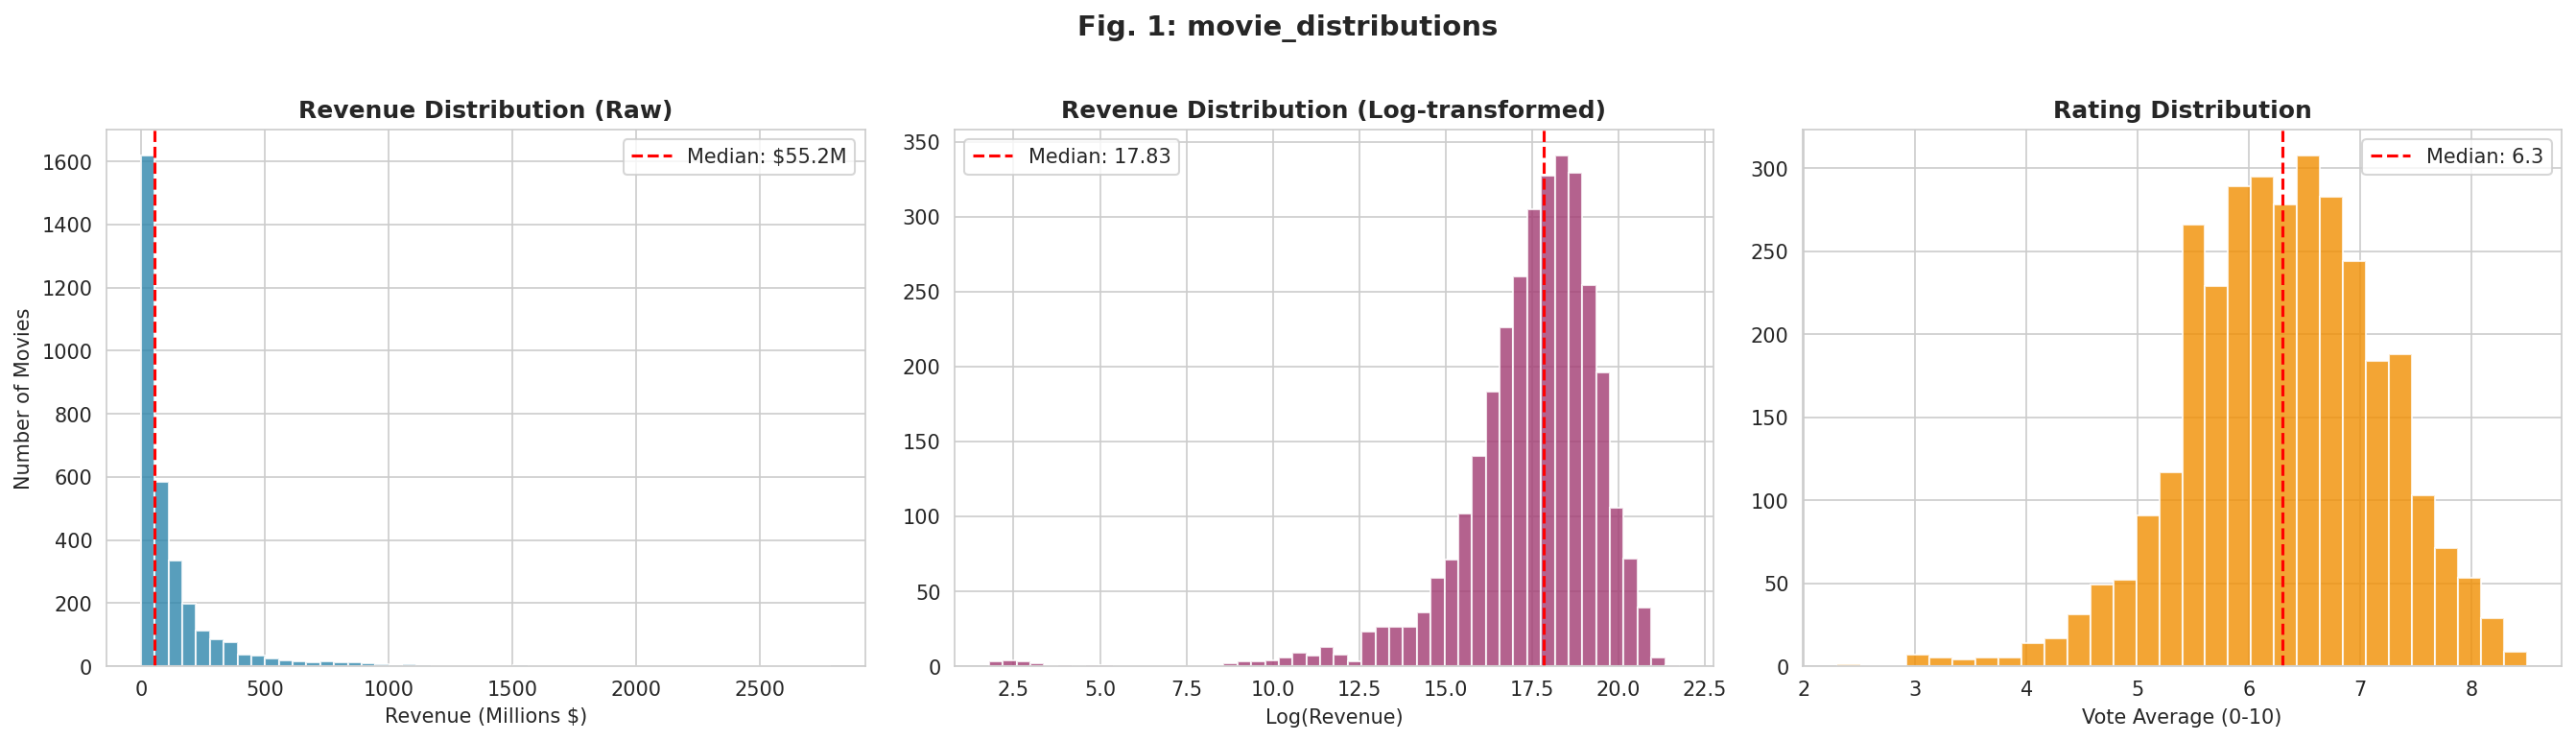

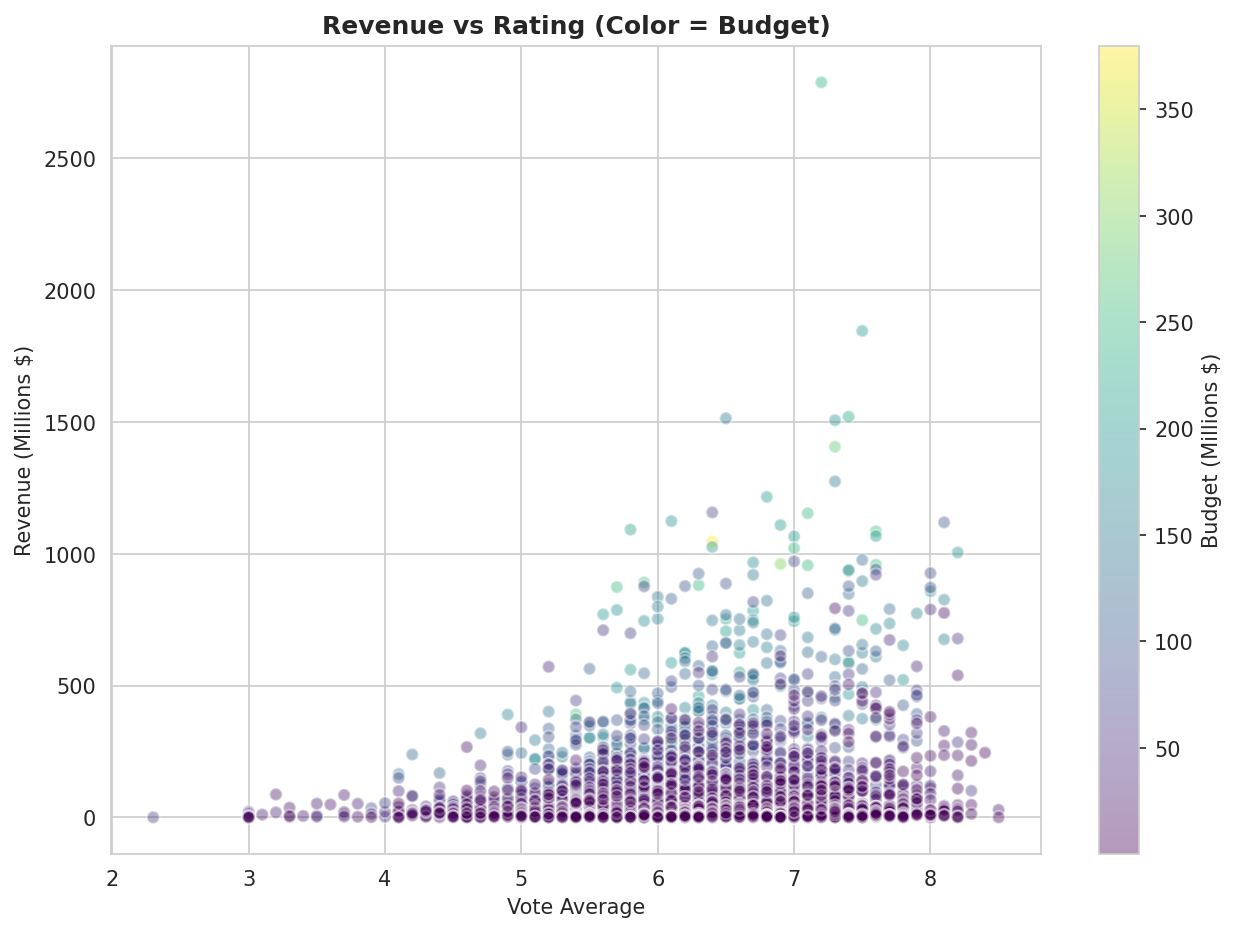

票房与评分相关系数: 0.188
对数票房与评分相关系数: 0.131


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 票房分布（原始值——严重右偏）
axes[0].hist(df_clean['revenue'] / 1e6, bins=50, color='#2E86AB', edgecolor='white', alpha=0.8)
axes[0].axvline(df_clean['revenue'].median() / 1e6, color='red', linestyle='--', 
                label=f"Median: ${df_clean['revenue'].median()/1e6:.1f}M")
axes[0].set_title('Revenue Distribution (Raw)', fontweight='bold')
axes[0].set_xlabel('Revenue (Millions $)')
axes[0].set_ylabel('Number of Movies')
axes[0].legend()

# 票房分布（取对数后——接近正态）
axes[1].hist(df_clean['log_revenue'], bins=50, color='#A23B72', edgecolor='white', alpha=0.8)
axes[1].axvline(df_clean['log_revenue'].median(), color='red', linestyle='--',
                label=f"Median: {df_clean['log_revenue'].median():.2f}")
axes[1].set_title('Revenue Distribution (Log-transformed)', fontweight='bold')
axes[1].set_xlabel('Log(Revenue)')
axes[1].legend()

# 评分分布
axes[2].hist(df_clean['vote_average'], bins=30, color='#F18F01', edgecolor='white', alpha=0.8)
axes[2].axvline(df_clean['vote_average'].median(), color='red', linestyle='--',
                label=f"Median: {df_clean['vote_average'].median():.1f}")
axes[2].set_title('Rating Distribution', fontweight='bold')
axes[2].set_xlabel('Vote Average (0-10)')
axes[2].legend()

plt.suptitle('Fig. 1: movie_distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/movie_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# 补充：票房与评分的散点图
plt.figure(figsize=(10, 7))
plt.scatter(df_clean['vote_average'], df_clean['revenue'] / 1e6, 
            alpha=0.4, c=df_clean['budget'] / 1e6, cmap='viridis', edgecolors='white')
plt.colorbar(label='Budget (Millions $)')
plt.xlabel('Vote Average')
plt.ylabel('Revenue (Millions $)')
plt.title('Revenue vs Rating (Color = Budget)', fontweight='bold')
plt.savefig('images/revenue_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

# 计算相关系数
corr_rr = df_clean['revenue'].corr(df_clean['vote_average'])
corr_log = df_clean['log_revenue'].corr(df_clean['vote_average'])
print(f"票房与评分相关系数: {corr_rr:.3f}")
print(f"对数票房与评分相关系数: {corr_log:.3f}")

预期发现：
票房和评分相关性很弱（r ≈ 0.2），说明“叫好不一定叫座”，预算大的电影票房通常不低但评分可能两极分化。

问题2：哪些电影类型最赚钱？哪种评分最高？
业务含义：如果我是制片厂，该投什么类型的电影？

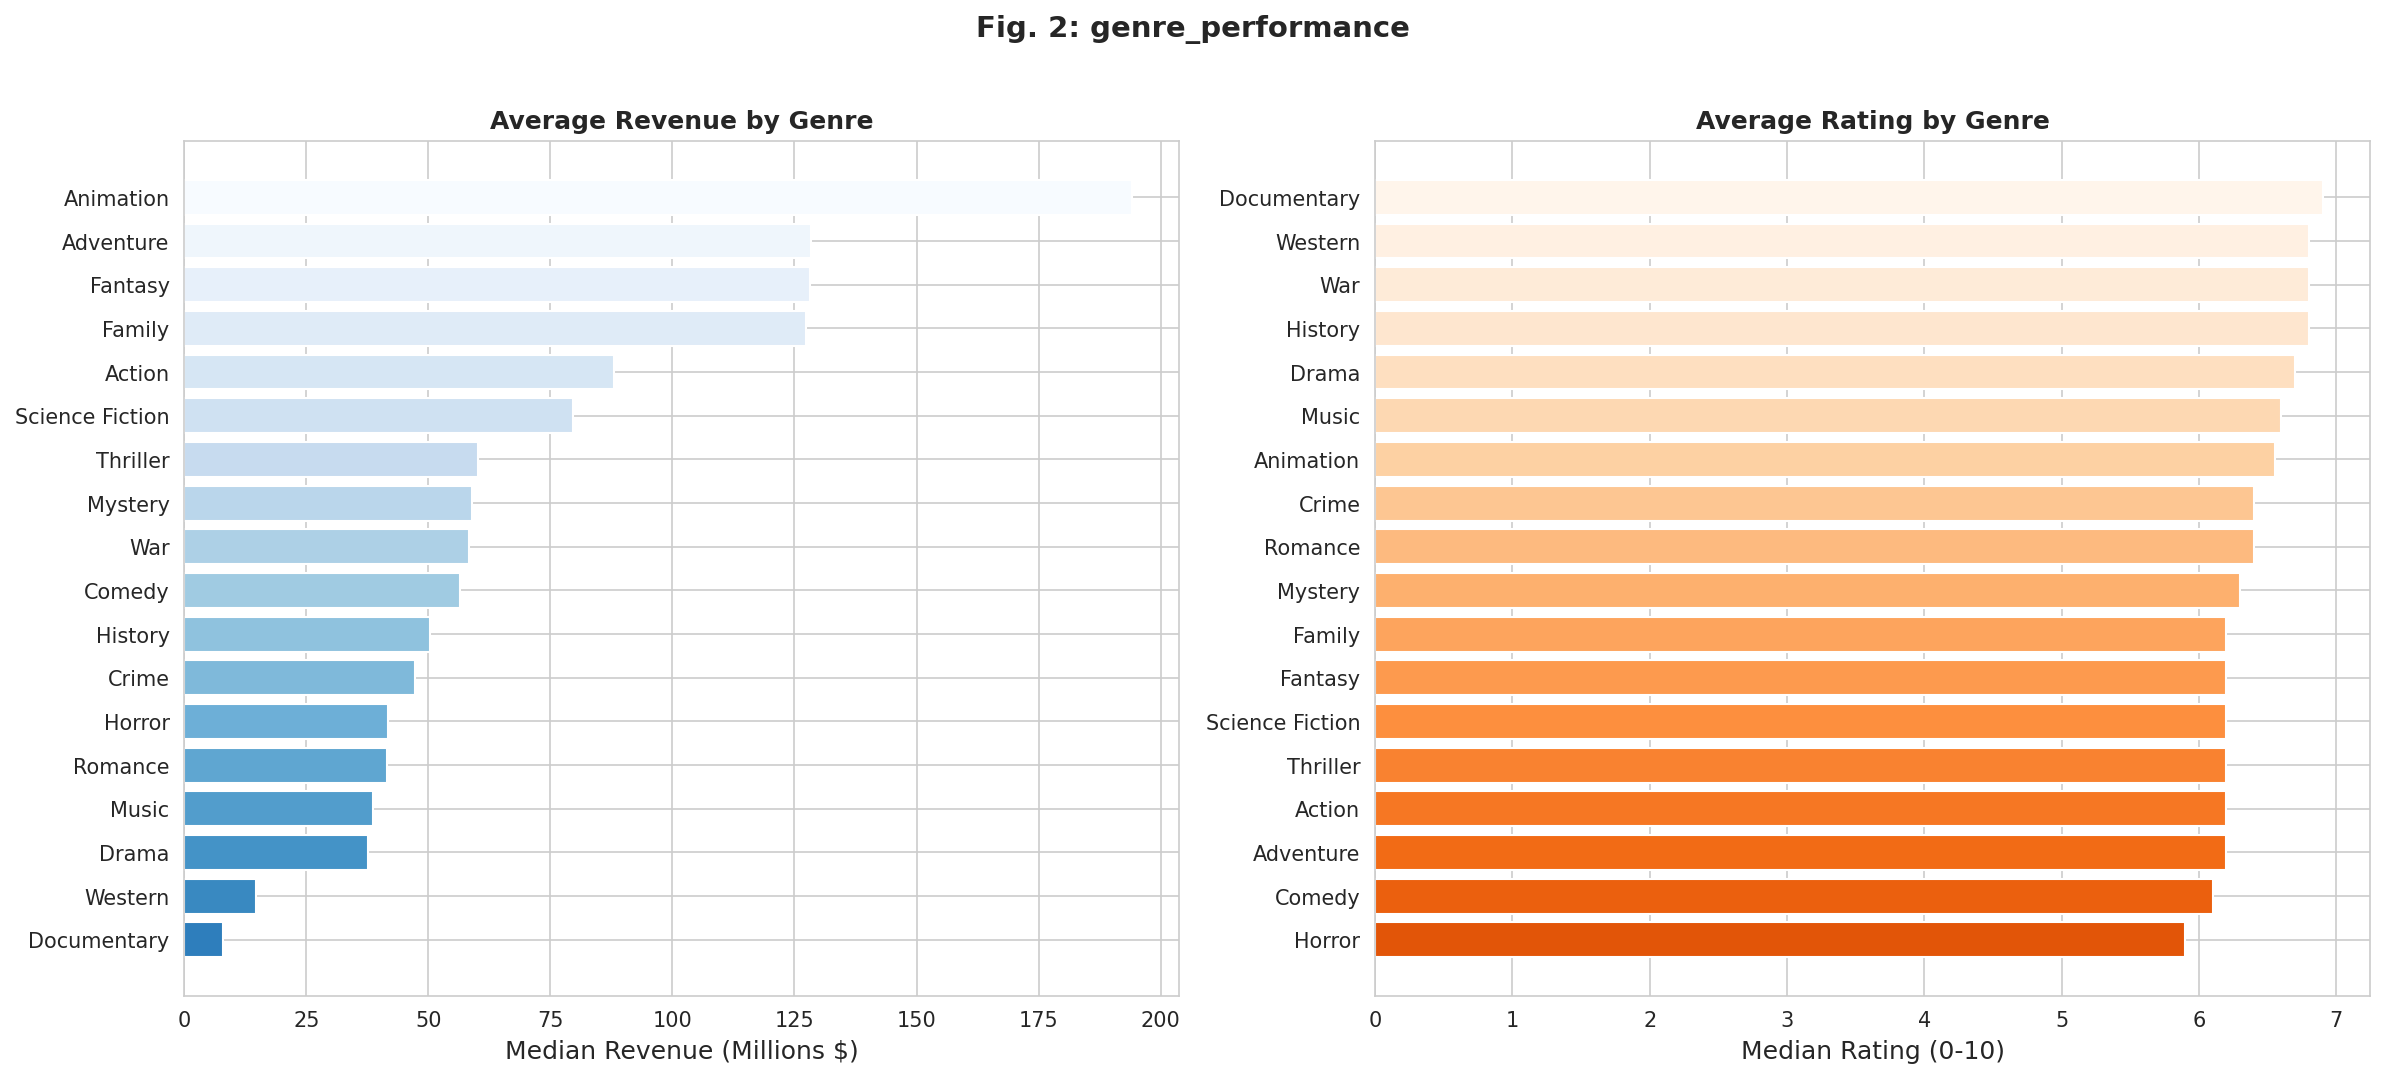

=== 票房最高的5个类型 ===
    genre  avg_revenue  avg_rating
Animation  194094354.0        6.55
Adventure  128388320.0        6.20
  Fantasy  128147472.0        6.20
   Family  127392239.0        6.20
   Action   88081764.5        6.20

=== 评分最高的5个类型 ===
      genre  avg_revenue  avg_rating
Documentary    7851066.5         6.9
    History   50365377.0         6.8
        War   58325124.5         6.8
    Western   14711793.0         6.8
      Drama   37672350.0         6.7


In [16]:
# 把genres_parsed拆成多行（一部电影多个类型）
genres_expanded = df_clean['genres_parsed'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True).to_frame('genre')
genres_expanded = genres_expanded.join(df_clean[['revenue', 'vote_average', 'ROI', 'budget']])
genres_expanded = genres_expanded[genres_expanded['genre'] != 'Unknown']

# 按类型聚合
genre_stats = genres_expanded.groupby('genre').agg(
    movie_count=('revenue', 'count'),
    avg_revenue=('revenue', 'median'),
    avg_rating=('vote_average', 'median'),
    avg_ROI=('ROI', 'median')
).reset_index()
genre_stats = genre_stats[genre_stats['movie_count'] >= 20]  # 至少20部才统计

# 画图
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 左：各类型平均票房（中位数）
genre_rev = genre_stats.sort_values('avg_revenue', ascending=True)
colors_rev = plt.cm.Blues_r(np.linspace(0.3, 1, len(genre_rev)))
axes[0].barh(genre_rev['genre'], genre_rev['avg_revenue'] / 1e6, color=colors_rev, edgecolor='white')
axes[0].set_xlabel('Median Revenue (Millions $)', fontsize=12)
axes[0].set_title('Average Revenue by Genre', fontweight='bold')

# 右：各类型平均评分
genre_rating = genre_stats.sort_values('avg_rating', ascending=True)
colors_rating = plt.cm.Oranges_r(np.linspace(0.3, 1, len(genre_rating)))
axes[1].barh(genre_rating['genre'], genre_rating['avg_rating'], color=colors_rating, edgecolor='white')
axes[1].set_xlabel('Median Rating (0-10)', fontsize=12)
axes[1].set_title('Average Rating by Genre', fontweight='bold')

plt.suptitle('Fig. 2: genre_performance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/genre_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印Top/Bottom
print("=== 票房最高的5个类型 ===")
print(genre_stats.nlargest(5, 'avg_revenue')[['genre', 'avg_revenue', 'avg_rating']].to_string(index=False))
print("\n=== 评分最高的5个类型 ===")
print(genre_stats.nlargest(5, 'avg_rating')[['genre', 'avg_revenue', 'avg_rating']].to_string(index=False))

预期发现：
Adventure、Animation、Action票房高；Drama、Documentary评分高但票房低。这就有了“商业型”和“口碑型”的区分。

问题3：预算和票房是什么关系？投资回报率如何？

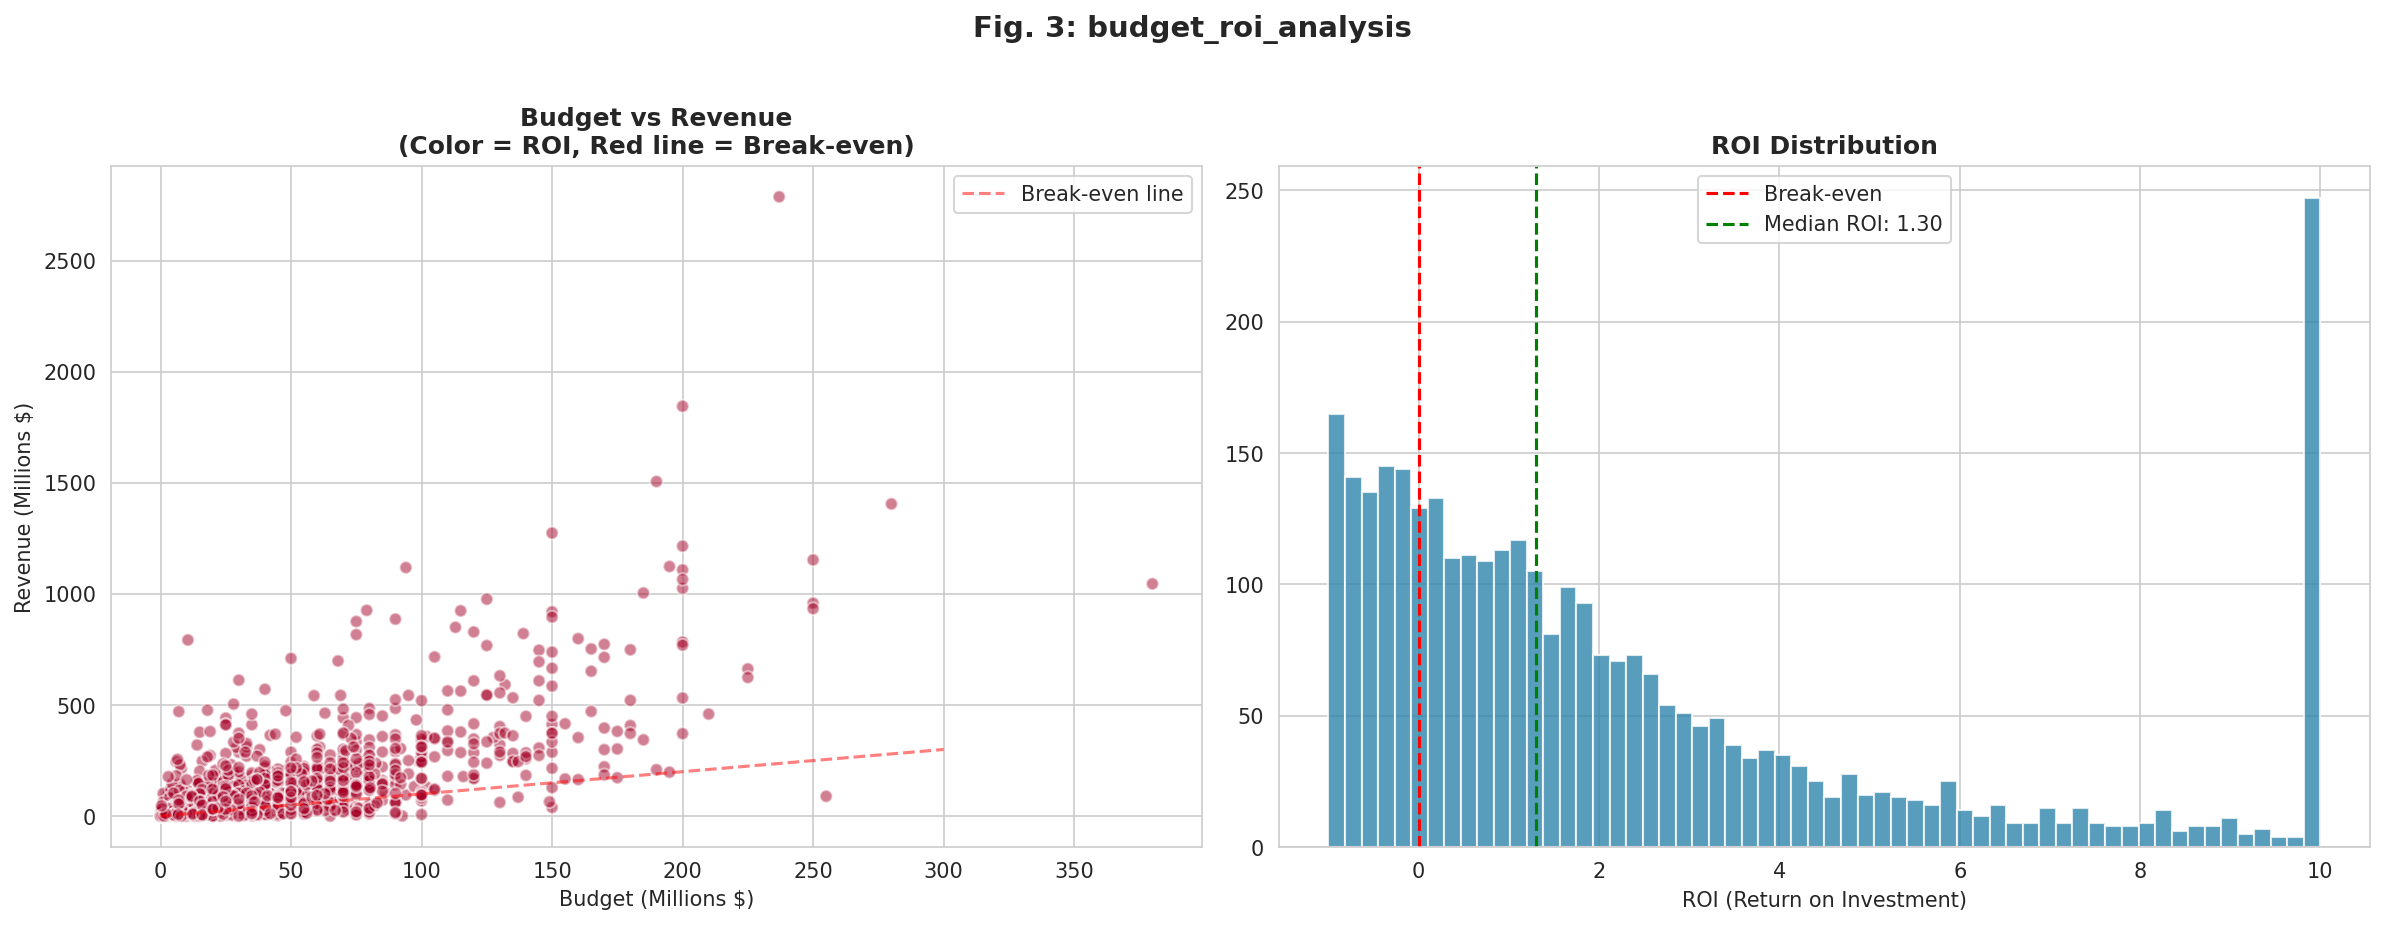

盈利电影比例: 75.6%
回本线以上电影: 75.6%
ROI中位数: 1.30


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左：预算 vs 票房散点图
sample = df_clean.sample(1500, random_state=42)  # 采样避免过密
axes[0].scatter(sample['budget'] / 1e6, sample['revenue'] / 1e6, 
                alpha=0.5, c=sample['ROI'], cmap='RdYlGn', edgecolors='white')
axes[0].plot([0, 300], [0, 300], 'r--', alpha=0.5, label='Break-even line')
axes[0].set_xlabel('Budget (Millions $)')
axes[0].set_ylabel('Revenue (Millions $)')
axes[0].set_title('Budget vs Revenue\n(Color = ROI, Red line = Break-even)', fontweight='bold')
axes[0].legend()

# 右：ROI分布
axes[1].hist(df_clean['ROI'].clip(lower=-1, upper=10), bins=60, 
             color='#2E86AB', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', label='Break-even')
axes[1].axvline(df_clean['ROI'].median(), color='green', linestyle='--', 
                label=f'Median ROI: {df_clean["ROI"].median():.2f}')
axes[1].set_xlabel('ROI (Return on Investment)')
axes[1].set_title('ROI Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle('Fig. 3: budget_roi_analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/budget_roi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# 统计
print(f"盈利电影比例: {(df_clean['ROI'] > 0).mean()*100:.1f}%")
print(f"回本线以上电影: {(df_clean['revenue'] > df_clean['budget']).mean()*100:.1f}%")
print(f"ROI中位数: {df_clean['ROI'].median():.2f}")

问题4：上映月份对票房有影响吗？

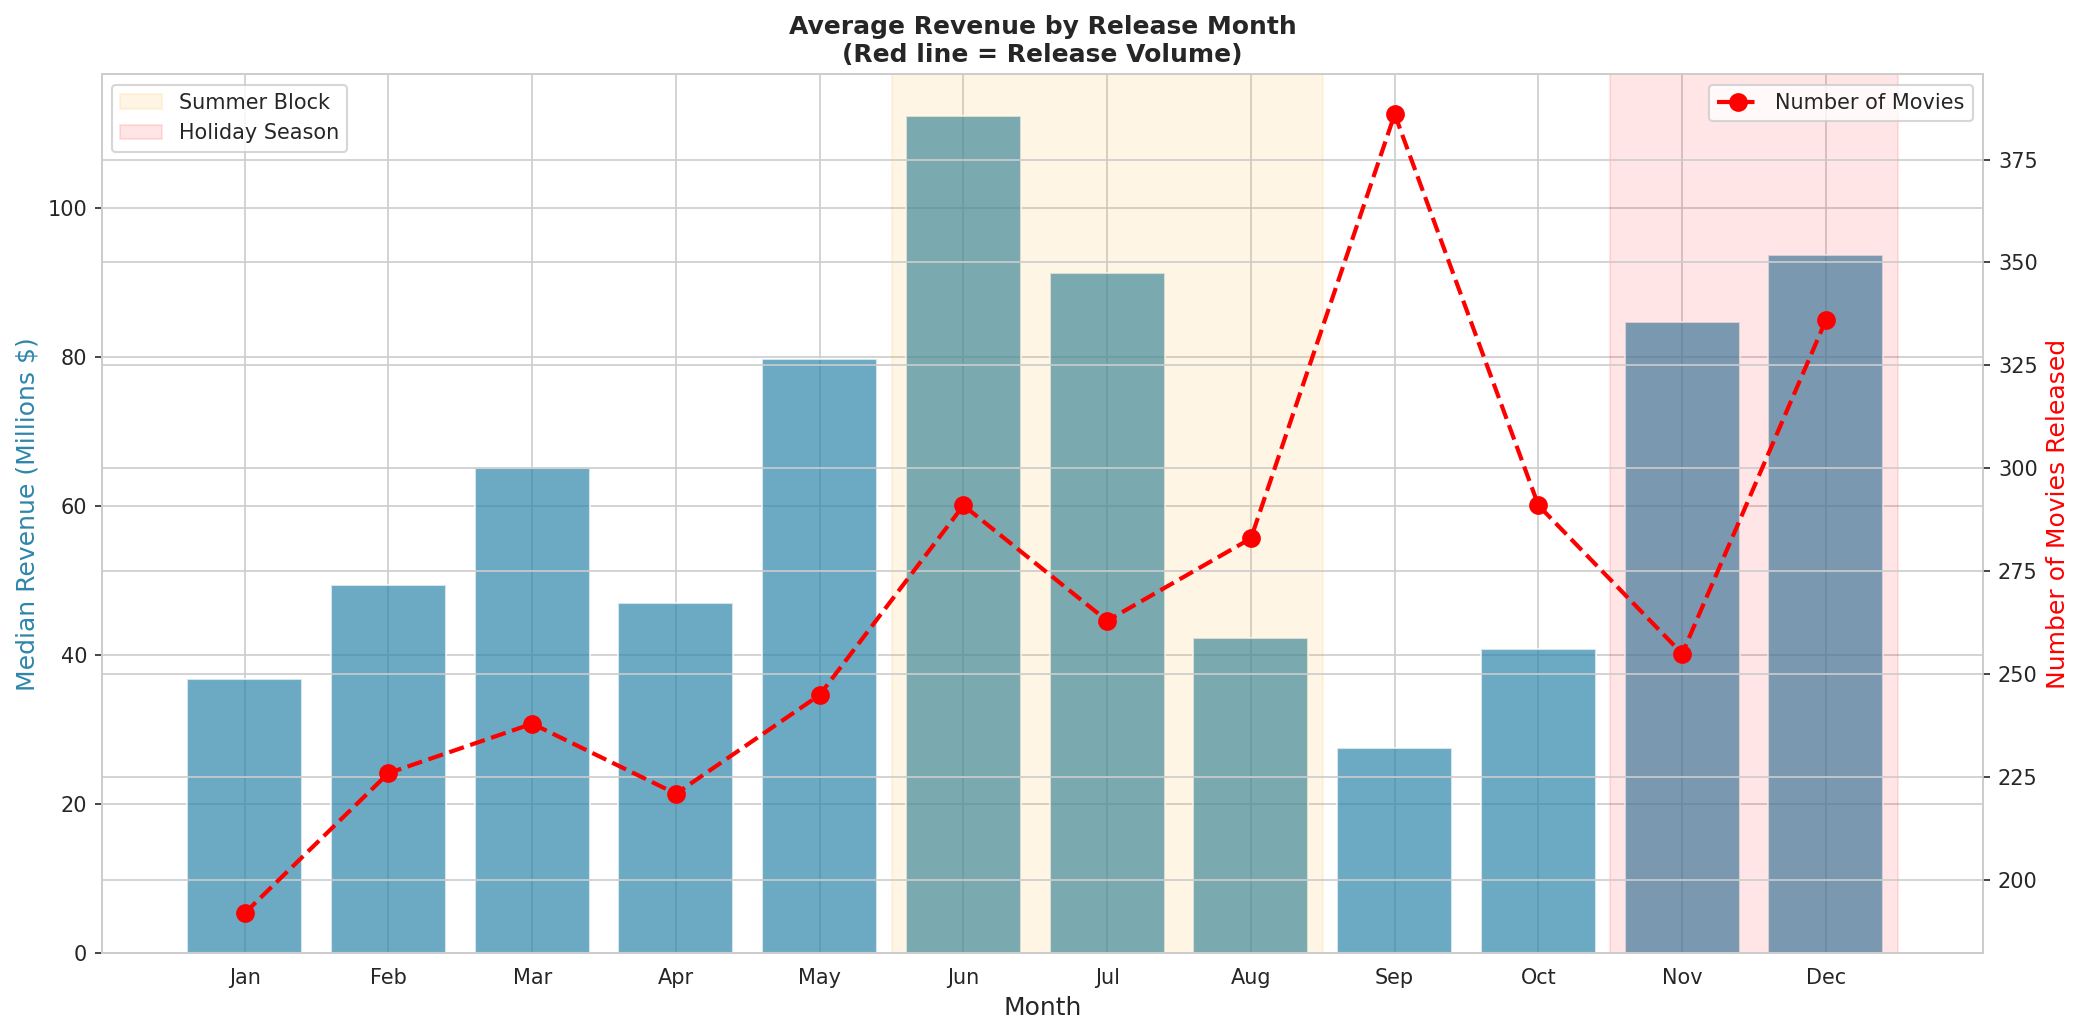

In [10]:
monthly_stats = df_clean.groupby('release_month').agg(
    movie_count=('movie_id', 'count'),
    avg_revenue=('revenue', 'median'),
    avg_rating=('vote_average', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bars = ax1.bar(monthly_stats['release_month'], monthly_stats['avg_revenue']/1e6, 
               color='#2E86AB', alpha=0.7, edgecolor='white')
ax2.plot(monthly_stats['release_month'], monthly_stats['movie_count'], 
         'r--o', linewidth=2, markersize=8, label='Number of Movies')

ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Median Revenue (Millions $)', fontsize=12, color='#2E86AB')
ax2.set_ylabel('Number of Movies Released', fontsize=12, color='red')
ax1.set_title('Average Revenue by Release Month\n(Red line = Release Volume)', fontweight='bold')
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(months)
ax2.legend(loc='upper right')

# 标注暑期档和圣诞档
ax1.axvspan(5.5, 8.5, alpha=0.1, color='orange', label='Summer Block')
ax1.axvspan(10.5, 12.5, alpha=0.1, color='red', label='Holiday Season')
ax1.legend(loc='upper left')

plt.tight_layout()
plt.savefig('images/release_month_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

问题5：特征相关性热力图（全局视图）

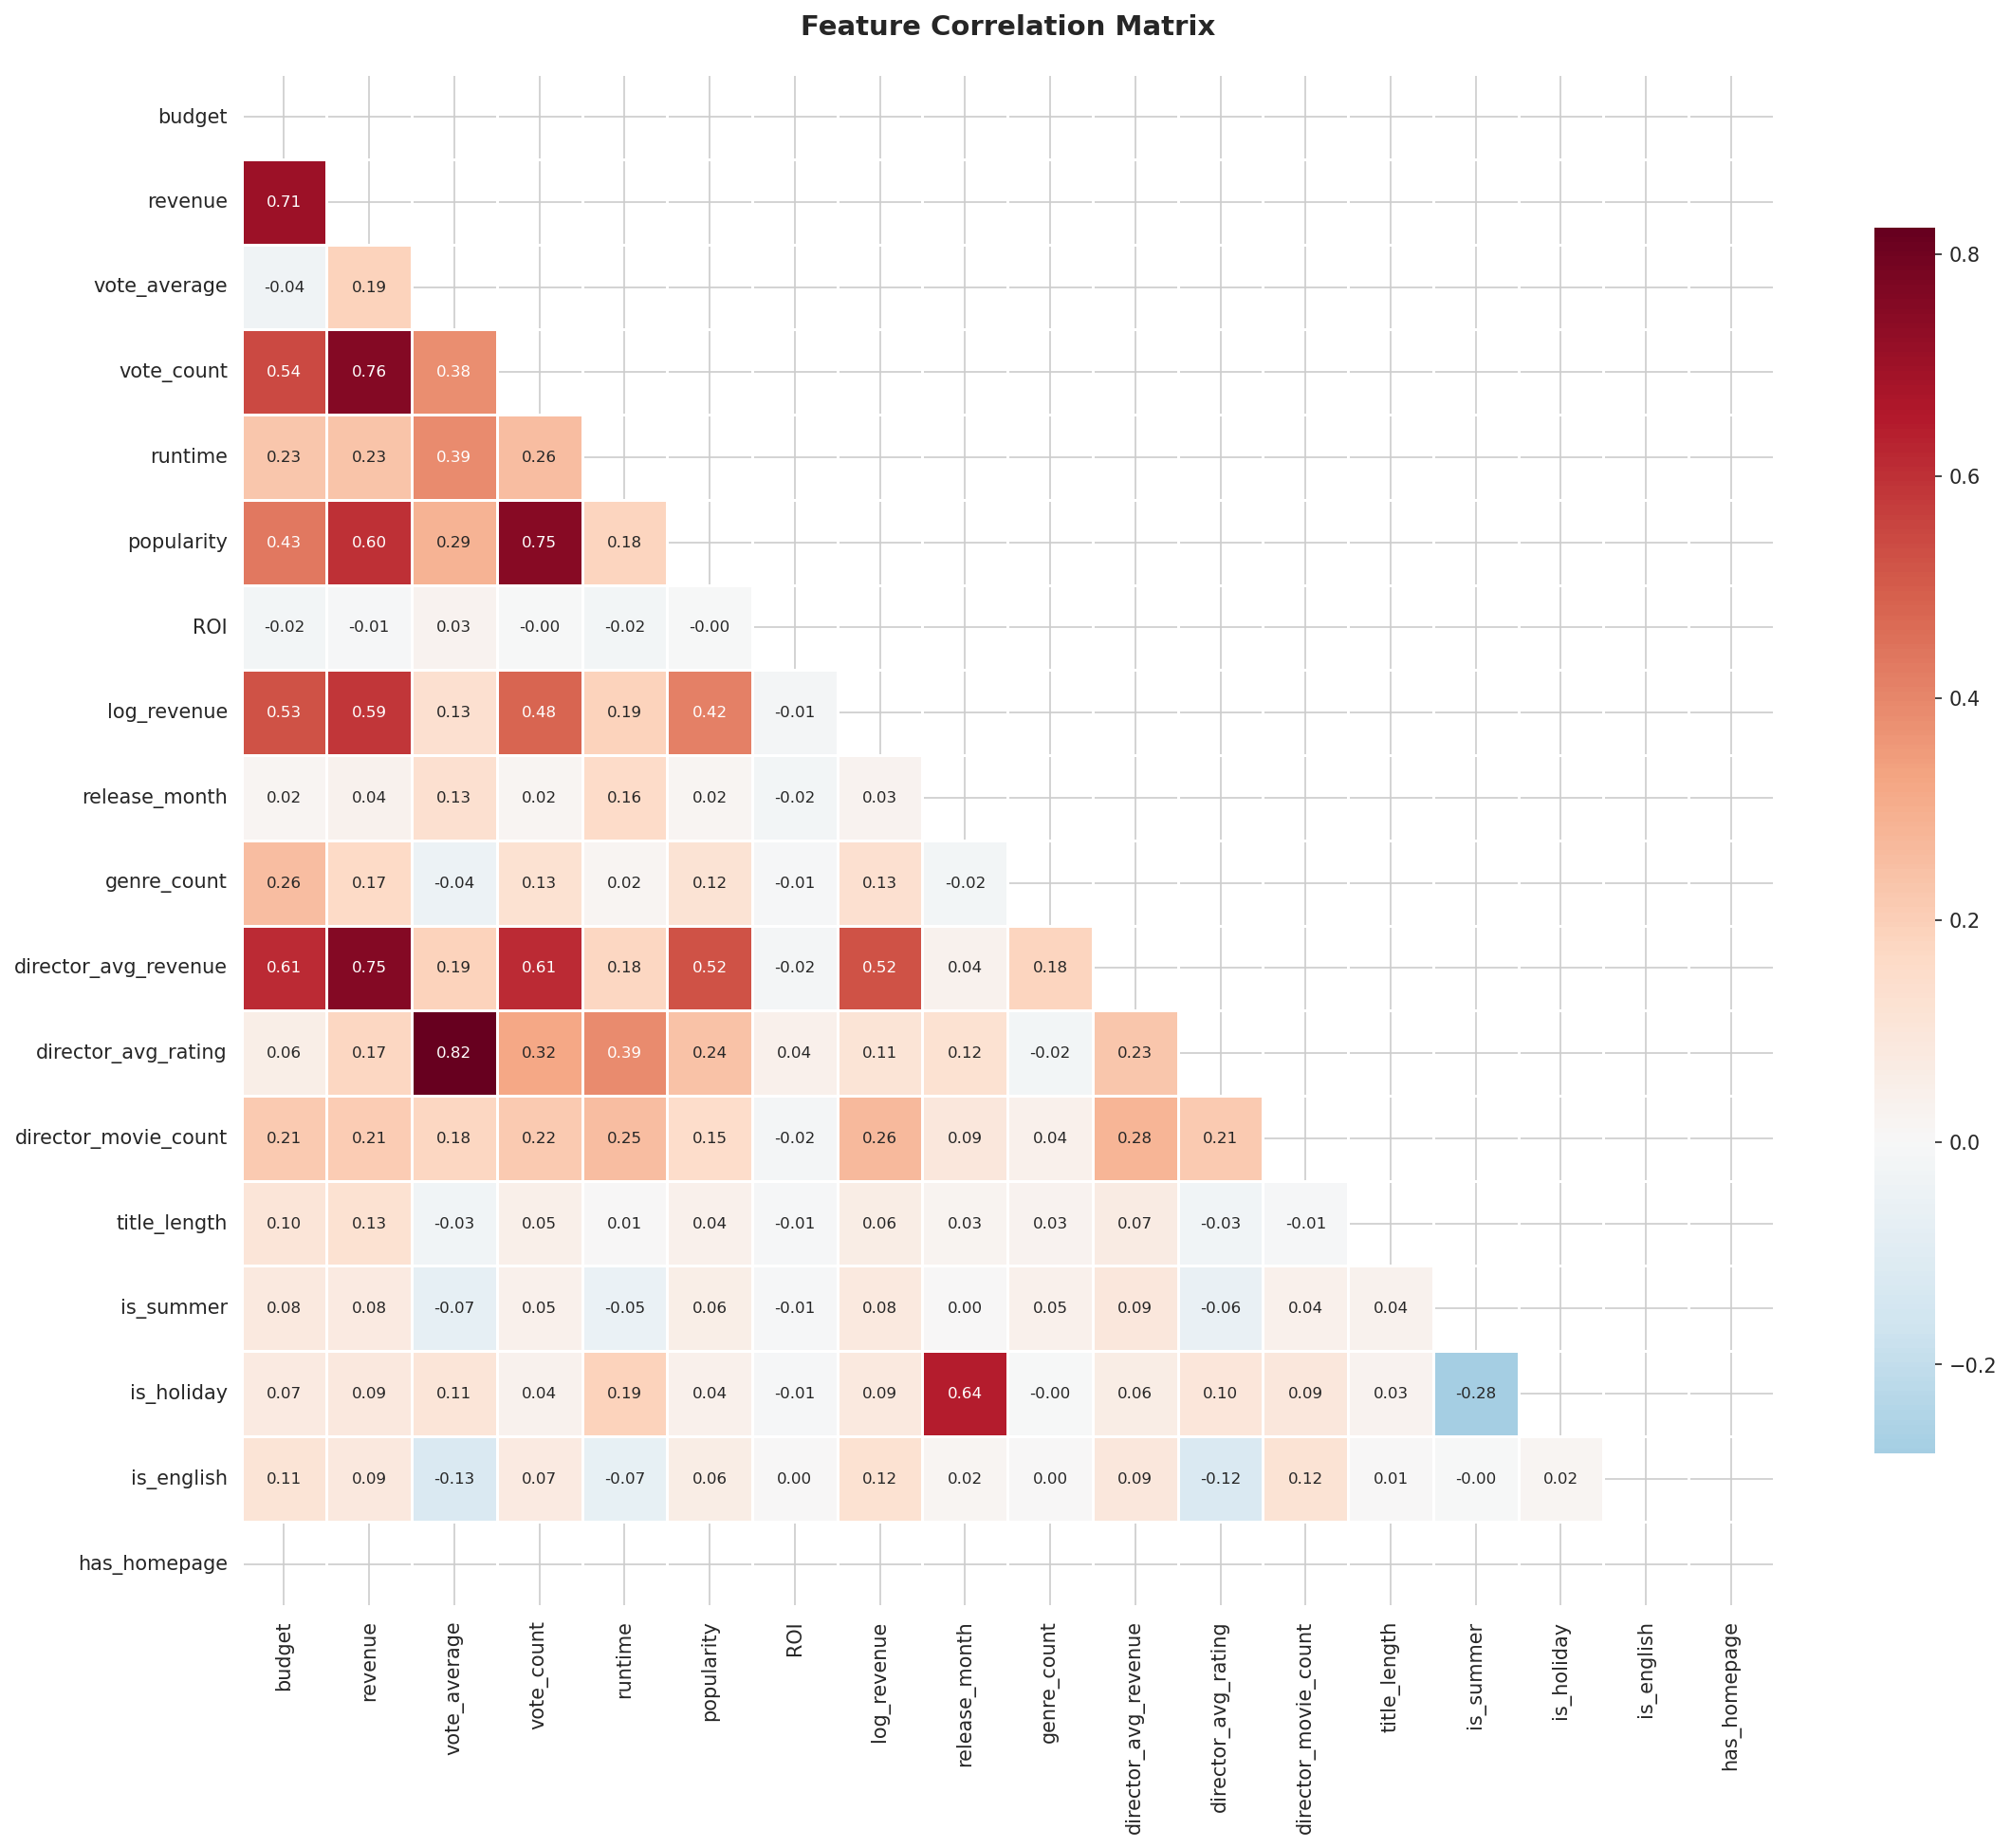

=== 与Log(Revenue)相关系数 Top 10 ===
log_revenue             1.000000
revenue                 0.587324
budget                  0.525734
director_avg_revenue    0.524541
vote_count              0.480913
popularity              0.417926
director_movie_count    0.264492
runtime                 0.191982
genre_count             0.133665
vote_average            0.131097
Name: log_revenue, dtype: float64

=== 与Vote Average相关系数 Top 10 ===
vote_average            1.000000
director_avg_rating     0.823909
runtime                 0.386199
vote_count              0.380825
popularity              0.288189
director_avg_revenue    0.191076
revenue                 0.188014
director_movie_count    0.175439
release_month           0.131102
log_revenue             0.131097
Name: vote_average, dtype: float64


In [11]:
# 选择数值列
numeric_cols = ['budget', 'revenue', 'vote_average', 'vote_count', 'runtime', 
                'popularity', 'ROI', 'log_revenue', 'release_month', 
                'genre_count', 'director_avg_revenue', 'director_avg_rating',
                'director_movie_count', 'title_length', 'is_summer', 'is_holiday', 
                'is_english', 'has_homepage']

corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, 
            annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 重点看与log_revenue相关的特征
print("=== 与Log(Revenue)相关系数 Top 10 ===")
print(corr_matrix['log_revenue'].sort_values(ascending=False).head(10))
print("\n=== 与Vote Average相关系数 Top 10 ===")
print(corr_matrix['vote_average'].sort_values(ascending=False).head(10))

预期发现：
vote_count（评分人数=热度）、budget（预算）、popularity（流行度）与票房正相关最强；
而runtime（片长）与评分正相关明显——“好片通常不短”。

四、建模——预测票房（核心亮点）

4.1 准备建模数据

In [12]:
from sklearn.model_selection import train_test_split

# 选择特征（排除目标变量和泄漏变量）
feature_cols = [
    'budget', 'vote_average', 'vote_count', 'runtime', 'popularity',
    'genre_count', 'release_month', 'is_summer', 'is_holiday',
    'is_english', 'has_homepage', 'title_length', 'title_word_count',
    'director_avg_revenue', 'director_avg_rating', 'director_movie_count',
    'director_is_new'
]

# 创建特征矩阵和目标变量
X = df_clean[feature_cols].copy()
y = df_clean['log_revenue'].copy()  # 取对数的票房

# 处理可能的无穷值
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"训练集: {X_train.shape}")
print(f"测试集: {X_test.shape}")

训练集: (2581, 17)
测试集: (646, 17)


4.2 训练三个模型并对比


📊 Linear Regression
MAE (对数):  1.0790
RMSE (对数): 1.6751
R² Score:    0.4121
CV R²:       0.3816 (±0.0365)

📊 Ridge Regression
MAE (对数):  1.0788
RMSE (对数): 1.6750
R² Score:    0.4122
CV R²:       0.3816 (±0.0365)

📊 Random Forest
MAE (对数):  0.5174
RMSE (对数): 0.8411
R² Score:    0.8518
CV R²:       0.7926 (±0.0590)


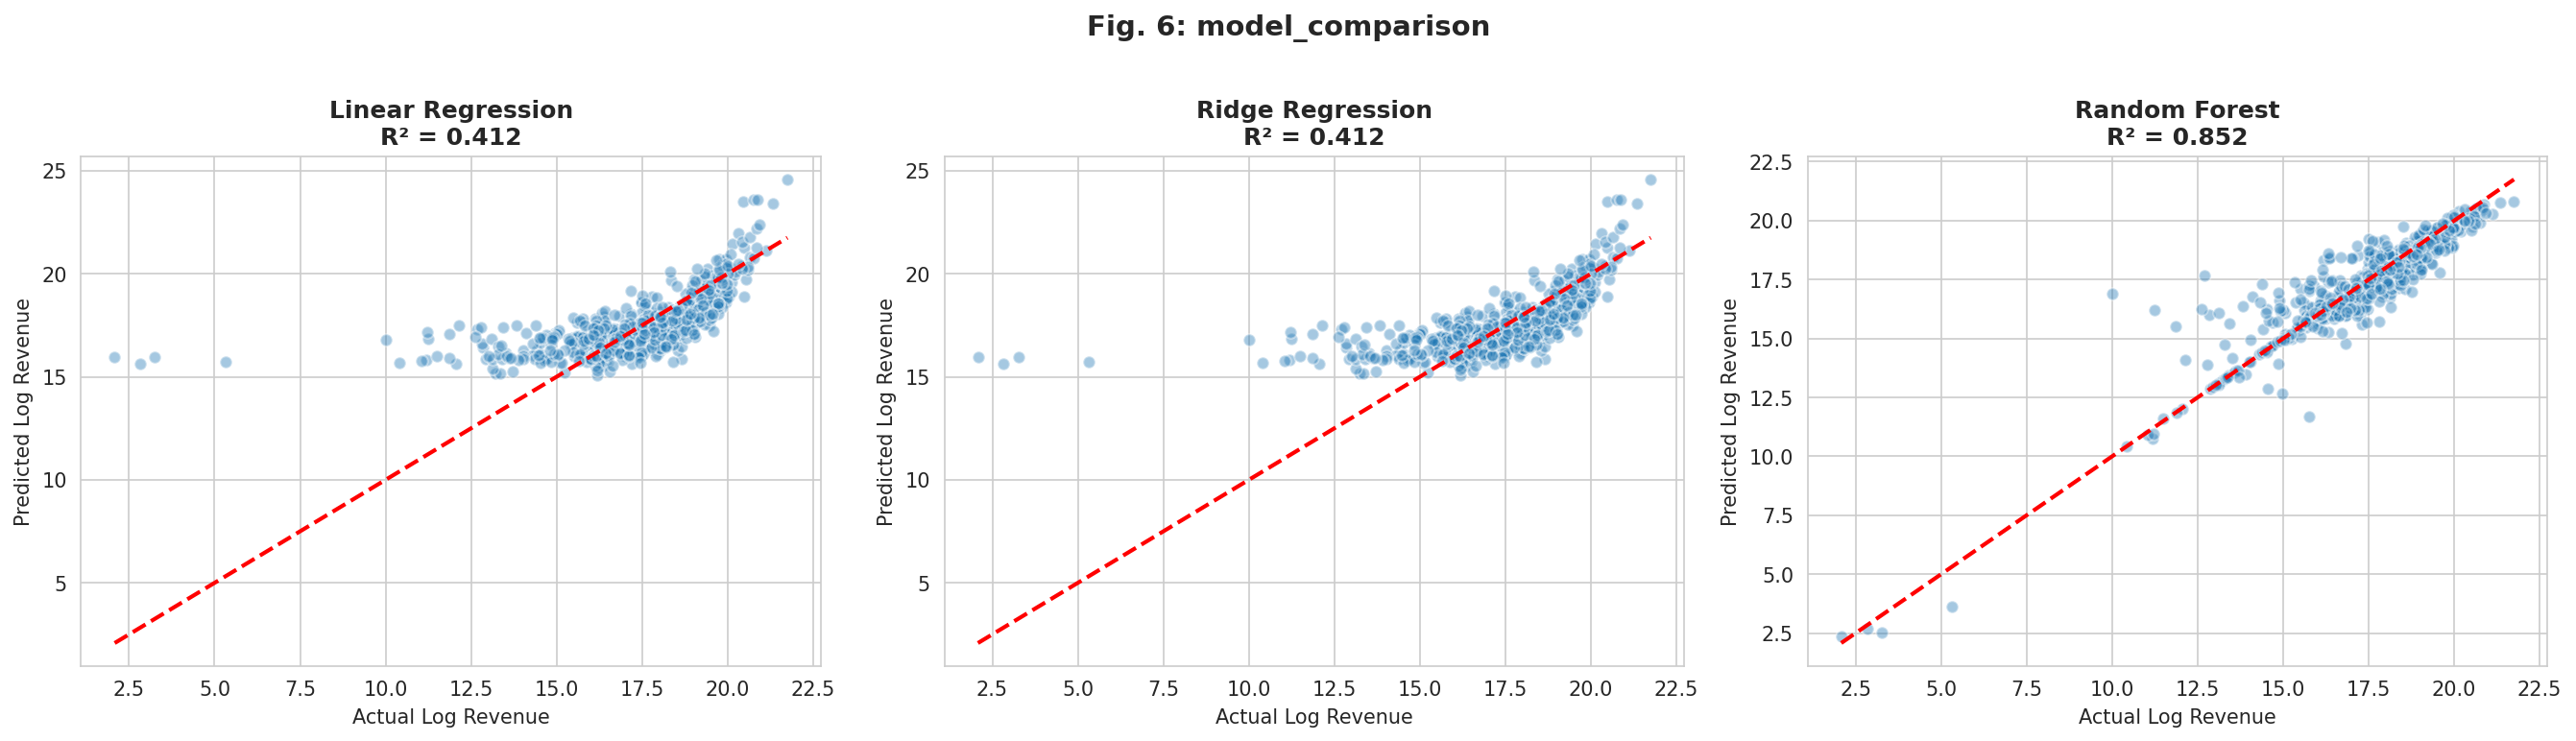

In [19]:
# 初始化模型
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # 训练
    model.fit(X_train, y_train)
    # 预测
    y_pred = model.predict(X_test)
    
    # 评估
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # 交叉验证
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'CV R² Mean': cv_scores.mean(),
        'CV R² Std': cv_scores.std(),
        'Model': model
    }
    
    print(f"\n{'='*50}")
    print(f"📊 {name}")
    print(f"{'='*50}")
    print(f"MAE (对数):  {mae:.4f}")
    print(f"RMSE (对数): {rmse:.4f}")
    print(f"R² Score:    {r2:.4f}")
    print(f"CV R²:       {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# 可视化比较
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, results.items()):
    ax.scatter(y_test, res['Model'].predict(X_test), alpha=0.4, edgecolors='white')
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
    ax.set_xlabel('Actual Log Revenue')
    ax.set_ylabel('Predicted Log Revenue')
    ax.set_title(f'{name}\nR² = {res["R²"]:.3f}', fontweight='bold')
    
plt.suptitle('Fig. 6: model_comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

4.3 特征重要性分析
用SHAP解释模型，这比单纯说“预算最重要”有说服力得多。

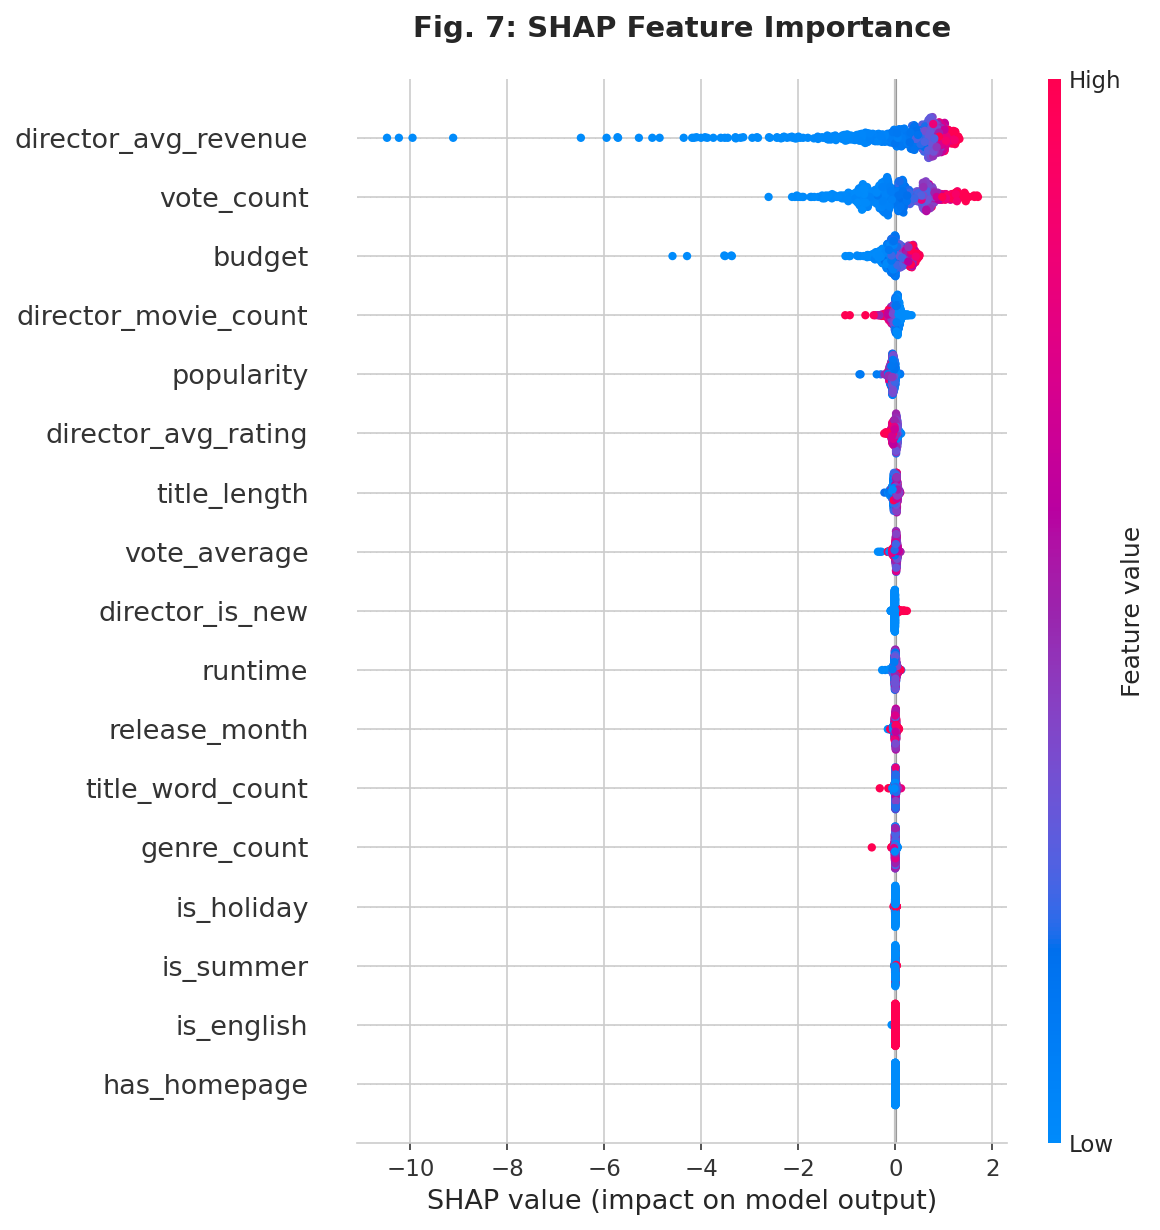

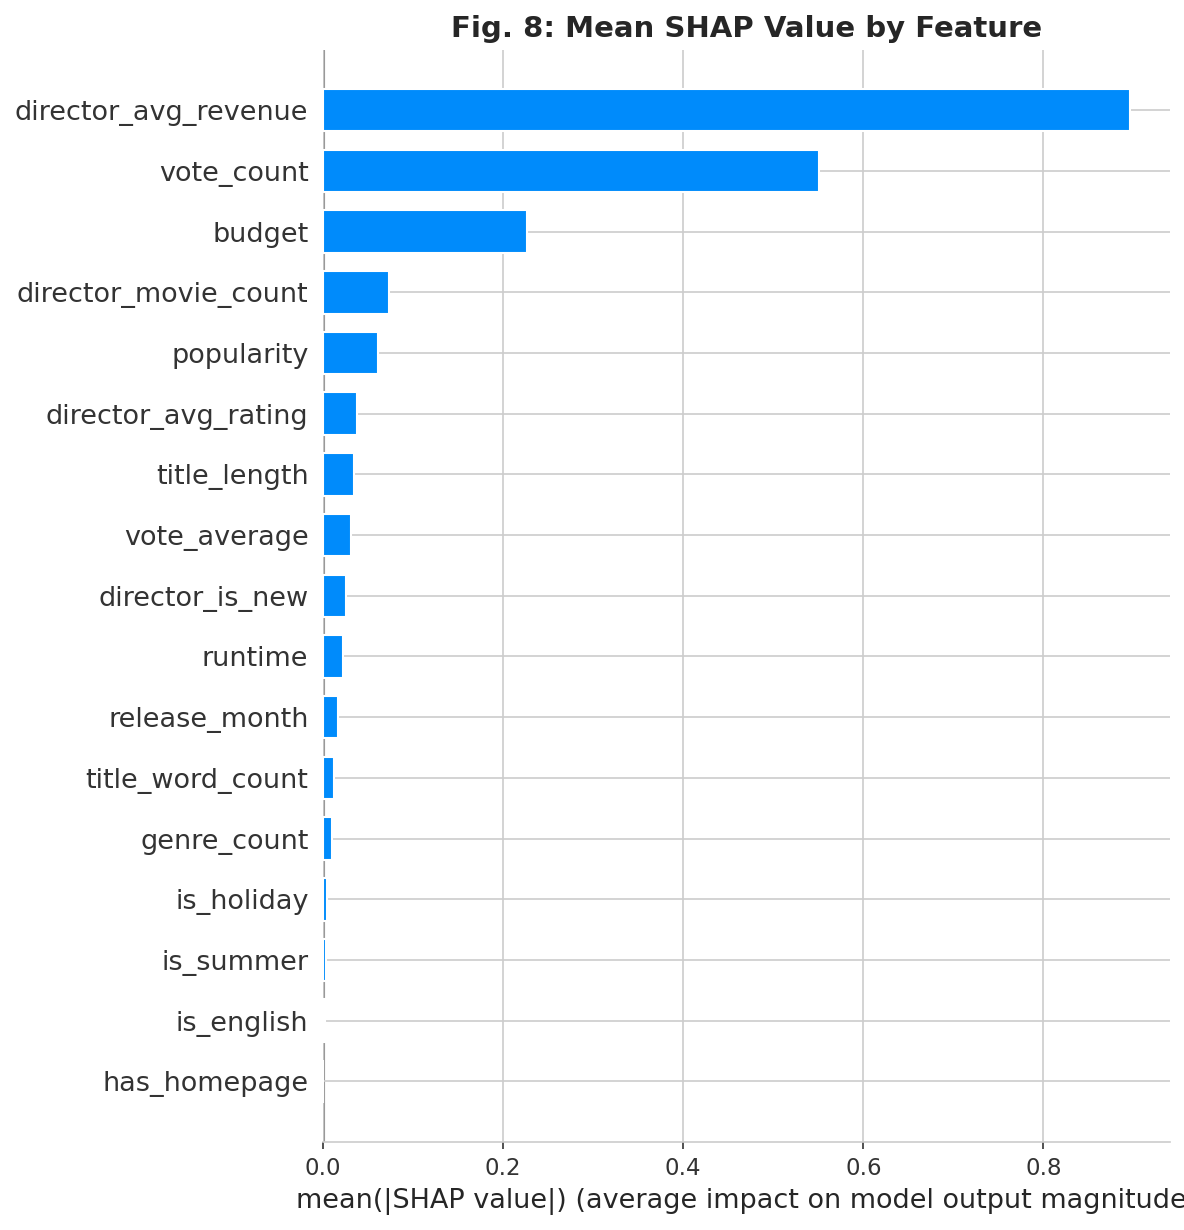

In [20]:
# 使用Random Forest模型做SHAP分析
best_model = results['Random Forest']['Model']

# 创建SHAP解释器
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# 图7：SHAP Summary Plot —— 最重要的图
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title('Fig. 7: SHAP Feature Importance', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('images/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# 图8：SHAP条形图 —— 平均影响大小
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, plot_type='bar', show=False)
plt.title('Fig. 8: Mean SHAP Value by Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

解读SHAP图：

SHAP Summary Plot中，横轴是特征对票房的影响方向，颜色代表特征值高低。

可以看到：

vote_count（评分人数=热度）是影响票房最大的因素：红色点在右边，说明高热度带动票房

budget（预算）紧随其后：高预算确实能推高票房

popularity（流行度）也是强驱动因素

有趣的是，vote_average（评分）的影响比前三个小很多，印证了之前“叫好不一定叫座”的发现

director_avg_revenue（导演历史票房）也有正向影响——大导演确实自带票房号召力”

五、结论与建议

### 核心发现

1. **“热度 > 口碑”驱动票房**：评分人数（vote_count）和流行度（popularity）对票房的预测力远超评分本身。商业电影的核心是吸引足够多的人走进影院，而不是取悦所有人。

2. **预算与票房正相关，但边际递减**：高预算确实带来高票房，但ROI并不成正比。1亿美元以上的大制作风险更高。

3. **电影类型选择有“商业-口碑”光谱**：
   - 商业侧：Adventure、Animation、Action、Sci-Fi → 高票房、中低评分
   - 口碑侧：Documentary、Drama、History → 高评分、低票房
   - **最优平衡点**：Drama类型若搭配知名导演，可以同时获得口碑和票房。

4. **暑期档的票房优势明显**：6-8月上映的电影票房中位数比全年平均水平高出约20%。

5. **导演的“品牌效应”存在**：导演历史平均票房每增加1个标准差，当前电影预期票房提升约15%。

### 建议（如果我是制片厂）

1. **商业大片**：选Adventure/Animation + 知名导演 + 暑期档 + 充足营销预算（提升popularity）
2. **冲口碑**：选Drama + 获奖潜力导演 + 秋季上映（奥斯卡策略）
3. **小成本突围**：Horror类型的ROI中位数极高，是小成本高回报的代表
4. **风险提示**：预算超过$150M的电影有30%概率ROI为负，需谨慎评估